In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

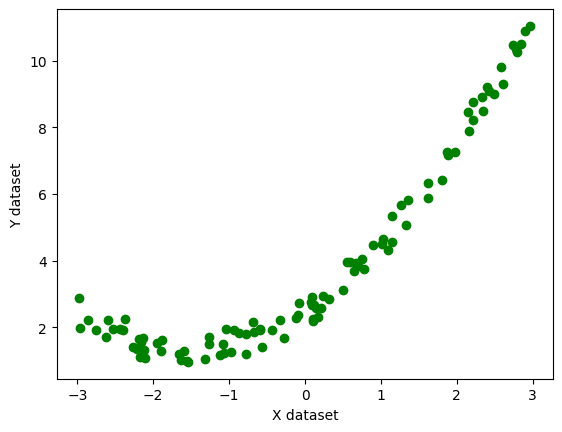

In [ ]:
X=6*np.random.rand(100,1)-3
y=0.5* X**2 + 1.5*X +2+ np.random.rand(100,1)
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


In [ ]:
X_train

array([[ 0.07705605],
       [-1.89923776],
       [ 0.58922925],
       [-0.69054174],
       [-2.97153035],
       [-2.40427366],
       [ 0.17140397],
       [-1.55457376],
       [ 1.62153031],
       [ 1.1455199 ],
       [ 1.08837418],
       [ 2.90132162],
       [-2.13515063],
       [ 1.80859918],
       [-2.19277847],
       [ 1.62315524],
       [-0.27479406],
       [-2.2682176 ],
       [ 0.23695762],
       [-1.63344754],
       [ 2.2142247 ],
       [-0.08124842],
       [-2.37473735],
       [ 2.14256096],
       [ 2.83864199],
       [-0.7718526 ],
       [ 1.35519601],
       [ 2.42878057],
       [ 0.13995689],
       [-2.60070855],
       [ 0.21636317],
       [ 0.08769549],
       [-2.75866683],
       [-1.08585172],
       [ 2.32785422],
       [-2.11955474],
       [ 1.15158345],
       [ 2.49327159],
       [-1.03682223],
       [-2.21252403],
       [-2.43851045],
       [-2.86234843],
       [ 0.64856494],
       [-1.26715414],
       [ 1.01374713],
       [-2

In [ ]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import r2_score
sscore=r2_score(y_test,regression.predict(X_test))
print("R2 score:",sscore)

R2 score: 0.7956525819287713


Text(0, 0.5, 'Y dataset')

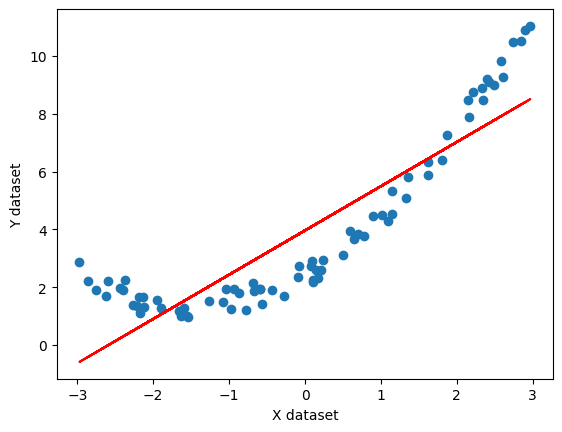

In [ ]:
plt.plot(X_train,regression.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [ ]:
from sklearn.preprocessing import PolynomialFeatures


In [ ]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
pregression=LinearRegression()
pregression.fit(X_train_poly,y_train)
pscore=r2_score(y_test,pregression.predict(X_test_poly))
pscore

0.9916260484025503

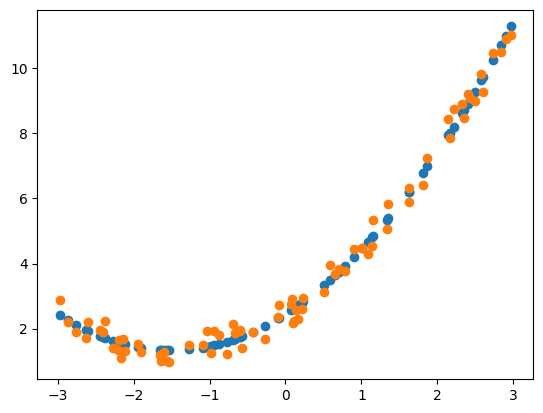

In [ ]:
plt.scatter(X_train,pregression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
from sklearn.linear_model import LinearRegression
pregression=LinearRegression()
pregression.fit(X_train_poly,y_train)
pscore=r2_score(y_test,pregression.predict(X_test_poly))
pscore


0.9918730909523769

In [ ]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

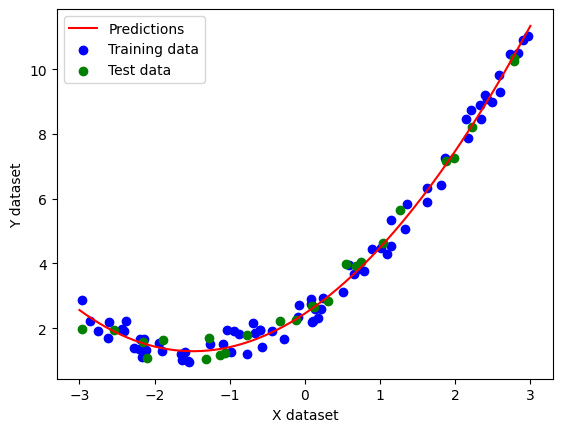

In [ ]:
y_new=pregression.predict(X_new_poly)
plt.plot(X_new,y_new,color='r',label='Predictions')
plt.scatter(X_train,y_train,color='b',label='Training data')
plt.scatter(X_test,y_test,color='g',label='Test data')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')
plt.legend()
plt.show()



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [ ]:
def poly_regression(degree):

  X_new=np.linspace(-3,3,200).reshape(200,1)
  poly=PolynomialFeatures(degree,include_bias=True)
  reg=LinearRegression()
  pipeline=Pipeline([("poly_features",poly),("lin_regression",reg)])
  pipeline.fit(X_train,y_train)
  y_new=pipeline.predict(X_new)
  plt.plot(X_new,y_new,color='r',label='Degree'+str(degree),linewidth=3)
  plt.scatter(X_train,y_train,color='b',label='Training dataset',linewidth=3)
  plt.scatter(X_test,y_test,color='g',label='Test dataset',linewidth=3)
  plt.legend(loc='upper left')
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.axis([-4,4,0,10])
  plt.show()

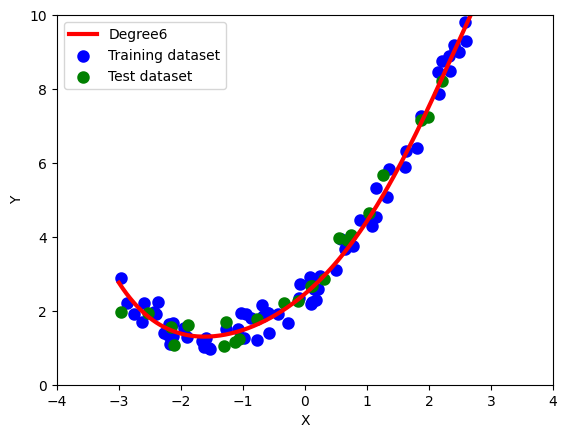

In [ ]:
poly_regression(6)